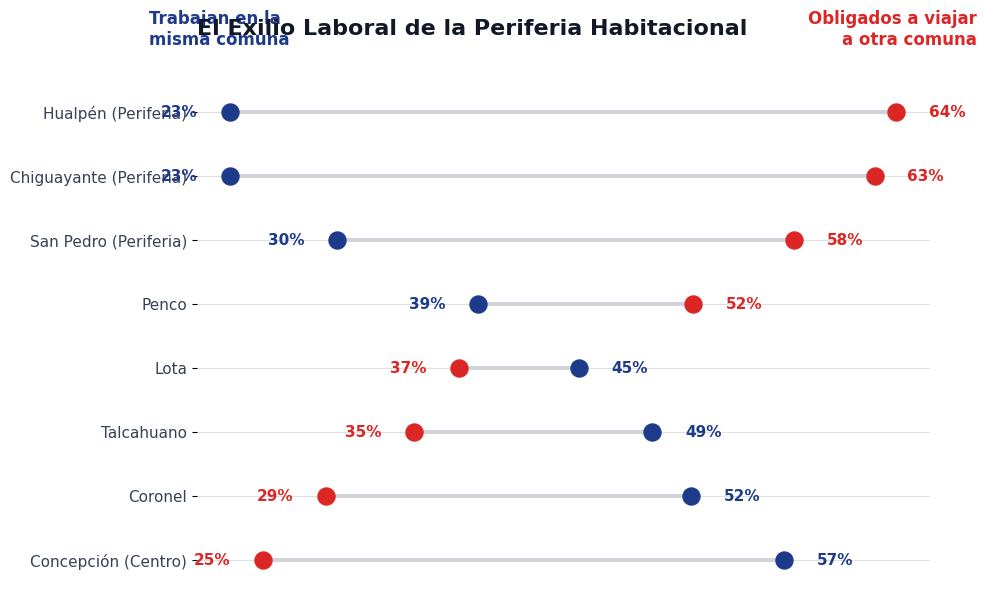

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargamos directo del raw solo las 2 columnas que necesitamos para no saturar la RAM (el CSV pesa 2.5GB)
df_censo = pd.read_csv('../data/raw/personas_censo2024.csv', sep=';', usecols=['comuna', 'p44_lug_trab'])

# 2. Filtramos el Gran Concepción
comunas_dict = {
    8101: 'Concepción (Centro)',
    8110: 'Talcahuano',
    8106: 'Lota',
    8102: 'Coronel',
    8107: 'Penco',
    8108: 'San Pedro (Periferia)',
    8103: 'Chiguayante (Periferia)',
    8112: 'Hualpén (Periferia)'
}

# Solo nos quedamos con los que tienen categoría de trabajo (1, 2 y 3) de estas comunas
df = df_censo[(df_censo['comuna'].isin(comunas_dict.keys())) & (df_censo['p44_lug_trab'].isin([1, 2, 3]))].copy()

# 3. Calculamos porcentajes
# p44_lug_trab -> 2: Misma comuna, 3: Otra comuna
agg = pd.crosstab(df['comuna'], df['p44_lug_trab'], normalize='index') * 100
agg.index = agg.index.map(comunas_dict)
agg = agg.rename(columns={2.0: 'Misma_Comuna', 3.0: 'Otra_Comuna'})

# Limpiamos y ordenamos
agg = agg[['Misma_Comuna', 'Otra_Comuna']].sort_values(by='Otra_Comuna', ascending=True)

# -------------------------------------------------------------
# 4. CONFIGURACIÓN VISUAL (Front-end simple, backend complejo)
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Limpieza absoluta de tinta (Reglas GEMINI.md)
for spyne in ['top', 'right', 'left', 'bottom']:
    ax.spines[spyne].set_visible(False)
ax.yaxis.grid(True, color='lightgray', linestyle='-', linewidth=0.5, zorder=0)
ax.xaxis.set_visible(False)

# Colores - Escala divergente (Azul = Integración / Rojo = Exilio)
c_same = '#1E3A8A' # Azul profundo
c_other = '#dc2626' # Rojo alerta

for i, (idx, row) in enumerate(agg.iterrows()):
    p_same = row['Misma_Comuna']
    p_other = row['Otra_Comuna']
    
    # Línea conector
    ax.plot([p_same, p_other], [i, i], color='#d1d5db', linewidth=3, zorder=1)
    
    # Puntos
    ax.scatter(p_same, i, color=c_same, s=150, zorder=2) 
    ax.scatter(p_other, i, color=c_other, s=150, zorder=2) 
    
    # Texto alineado inteligentemente para que no se choque
    offset = 2.0
    if p_same > p_other:
        ax.text(p_same + offset, i, f'{p_same:.0f}%', va='center', ha='left', color=c_same, fontweight='bold', fontsize=11)
        ax.text(p_other - offset, i, f'{p_other:.0f}%', va='center', ha='right', color=c_other, fontweight='bold', fontsize=11)
    else:
        ax.text(p_same - offset, i, f'{p_same:.0f}%', va='center', ha='right', color=c_same, fontweight='bold', fontsize=11)
        ax.text(p_other + offset, i, f'{p_other:.0f}%', va='center', ha='left', color=c_other, fontweight='bold', fontsize=11)

# Eje Y limpio
ax.set_yticks(range(len(agg)))
ax.set_yticklabels(agg.index, fontsize=11, fontweight='500', color='#374151')

# Leyenda customizada sin caja y como titular
ax.text(agg.min().min() - 5, len(agg), 'Trabajan en la\nmisma comuna', color=c_same, fontweight='bold', ha='left', va='bottom', fontsize=12)
ax.text(agg.max().max() + 5, len(agg), 'Obligados a viajar\na otra comuna', color=c_other, fontweight='bold', ha='right', va='bottom', fontsize=12)

plt.title('El Exilio Laboral de la Periferia Habitacional', 
          fontsize=16, loc='left', fontweight='heavy', pad=40, color='#111827')

# Guardamos el resultado en alta calidad
plt.tight_layout()
plt.savefig('../deliverables/grafico_censo_exilio_laboral.png', dpi=300, bbox_inches='tight')
plt.show()
